# Spatial distribution of Percentile precipitation over India

Years available:
[1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024 2025]
Row 1/201
Row 2/201
Row 3/201
Row 4/201
Row 5/201
Row 6/201
Row 7/201
Row 8/201
Row 9/201
Row 10/201
Row 11/201
Row 12/201
Row 13/201
Row 14/201
Row 15/201
Row 16/201
Row 17/201
Row 18/201
Row 19/201
Row 20/201
Row 21/201
Row 22/201
Row 23/201
Row 24/201
Row 25/201
Row 26/201
Row 27/201
Row 28/201
Row 29/201
Row 30/201
Row 31/201
Row 32/201
Row 33/201
Row 34/201
Row 35/201
Row 36/201
Row 37/201
Row 38/201
Row 39/201
Row 40/201
Row 41/201
Row 42/201
Row 43/201
Row 44/201
Row 45/201
Row 46/201
Row 47/201
Row 48/201
Row 49/201
Row 50/201
Row 51/201
Row 52/201
Row 53/201
Row 54/201
Row 55/201
Row 56/201
Row 57/201
Row 58/201
Row 59/201
Row 60/201
Row 61/201
Row 62/201
Row 63/201
Row 64/201
Row 65/201
Row 66/201
Row 67/201
Row 68/201
Row 69/20

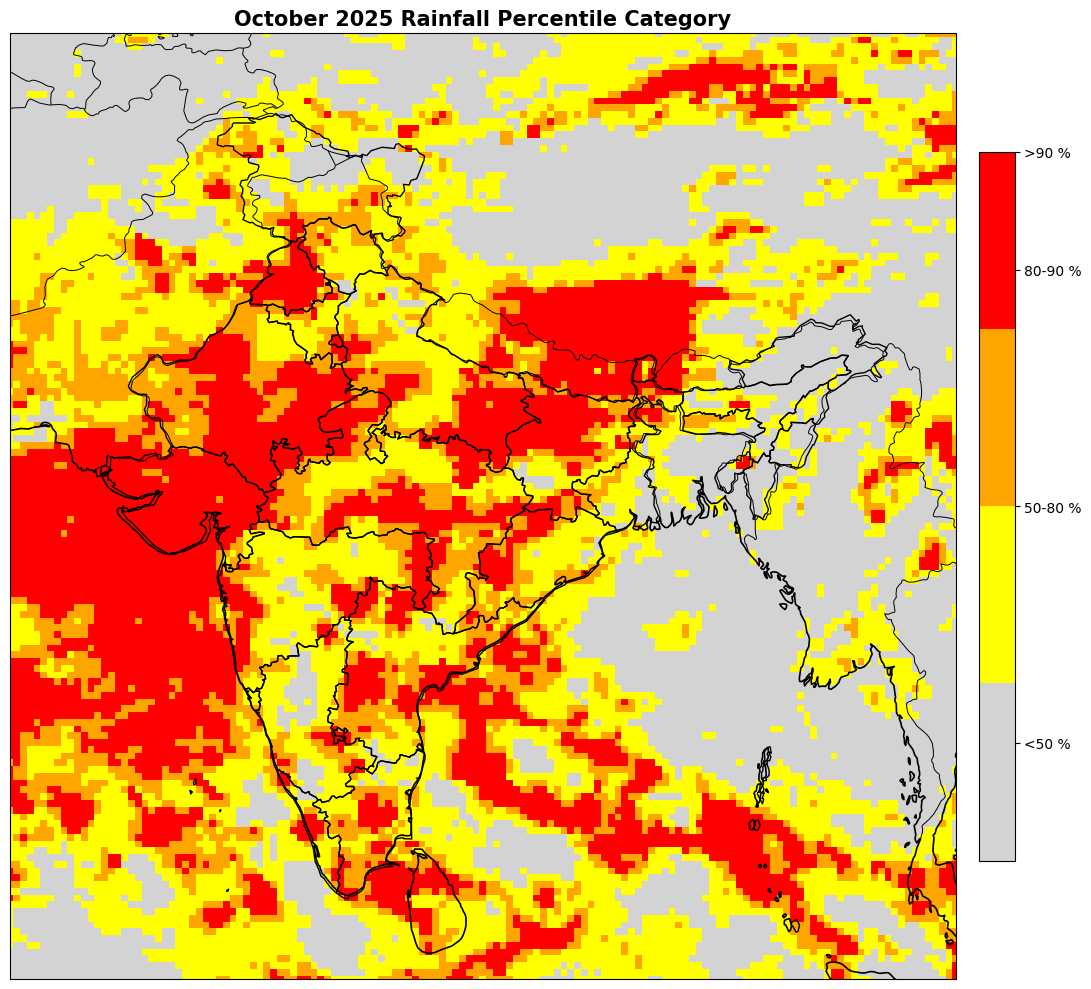

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import percentileofscore
from matplotlib.colors import ListedColormap

# =====================================================
# USER INPUTS
# =====================================================

rain_file = r"D:\PHD 2025~\1.SERVER_1\DATA\1.PRECIPITATION\ERA5_merged_1980_2026_new.nc"

india_shp = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\india_st.shp"

lon_min = 65
lon_max = 100

lat_min = 5
lat_max = 40

target_year = 2025

# =====================================================
# READ DATA
# =====================================================

ds = xr.open_dataset(rain_file)

tp = ds["tp"]

# ERA5 precipitation is in meters
tp = tp * 1000.0   # convert to mm

# =====================================================
# OCTOBER TOTAL FOR EVERY YEAR
# =====================================================

oct_data = tp.where(tp.valid_time.dt.month == 10, drop=True)

oct_totals = (
    oct_data
    .groupby("valid_time.year")
    .sum(dim="valid_time")
)

years = oct_totals.year.values

print("Years available:")
print(years)

# =====================================================
# TARGET YEAR OCT TOTAL
# =====================================================

target_oct = oct_totals.sel(year=target_year)

# =====================================================
# PERCENTILE OF 2025 OCT TOTAL
# =====================================================

ny, nx = target_oct.shape

percentile_grid = np.full((ny, nx), np.nan)

all_oct = oct_totals.values

for i in range(ny):
    print(f"Row {i+1}/{ny}")

    for j in range(nx):

        clim_series = all_oct[:, i, j]

        if np.all(np.isnan(clim_series)):
            continue

        target_value = target_oct.values[i, j]

        percentile_grid[i, j] = percentileofscore(
            clim_series,
            target_value,
            kind="weak"
        )

# =====================================================
# CLASSIFICATION
# =====================================================

classes = np.full_like(percentile_grid, np.nan)

classes[(percentile_grid < 50)] = 1

classes[(percentile_grid >= 50) &
        (percentile_grid < 80)] = 2

classes[(percentile_grid >= 80) &
        (percentile_grid < 90)] = 3

classes[(percentile_grid >= 90)] = 4

# =====================================================
# LAT/LON
# =====================================================

lon = ds.longitude.values
lat = ds.latitude.values

# =====================================================
# INDIA SHAPEFILE
# =====================================================

india = gpd.read_file(india_shp)

# =====================================================
# COLORS
# CHANGE THESE LATER
# =====================================================

colors = [
    "lightgrey",     # <50
    "yellow",        # 50-80
    "orange",        # 80-90
    "red"            # >90
]

cmap = ListedColormap(colors)

# =====================================================
# PLOT
# =====================================================

fig = plt.figure(figsize=(12,10))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [lon_min, lon_max,
     lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

# 250 m coastline
ax.coastlines(
    resolution="50m",
    linewidth=1.2
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.7
)

# =====================================================
# GRID CLASS MAP
# =====================================================

mesh = ax.pcolormesh(
    lon,
    lat,
    classes,
    cmap=cmap,
    vmin=1,
    vmax=4,
    shading="auto",
    transform=ccrs.PlateCarree()
)

india.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.0,
    transform=ccrs.PlateCarree()
)

# =====================================================
# COLORBAR
# =====================================================

cbar = plt.colorbar(
    mesh,
    ax=ax,
    shrink=0.75,
    pad=0.02
)

cbar.set_ticks([1.5, 2.5, 3.5, 4])

cbar.set_ticklabels([
    "<50 %",
    "50-80 %",
    "80-90 %",
    ">90 %"
])

# =====================================================
# TITLE
# =====================================================

plt.title(
    f"October {target_year} Rainfall Percentile Category",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Timeseries Bar plot for IMD grided (0.25 X 0.25 Degrees) rainfall time series for 2025

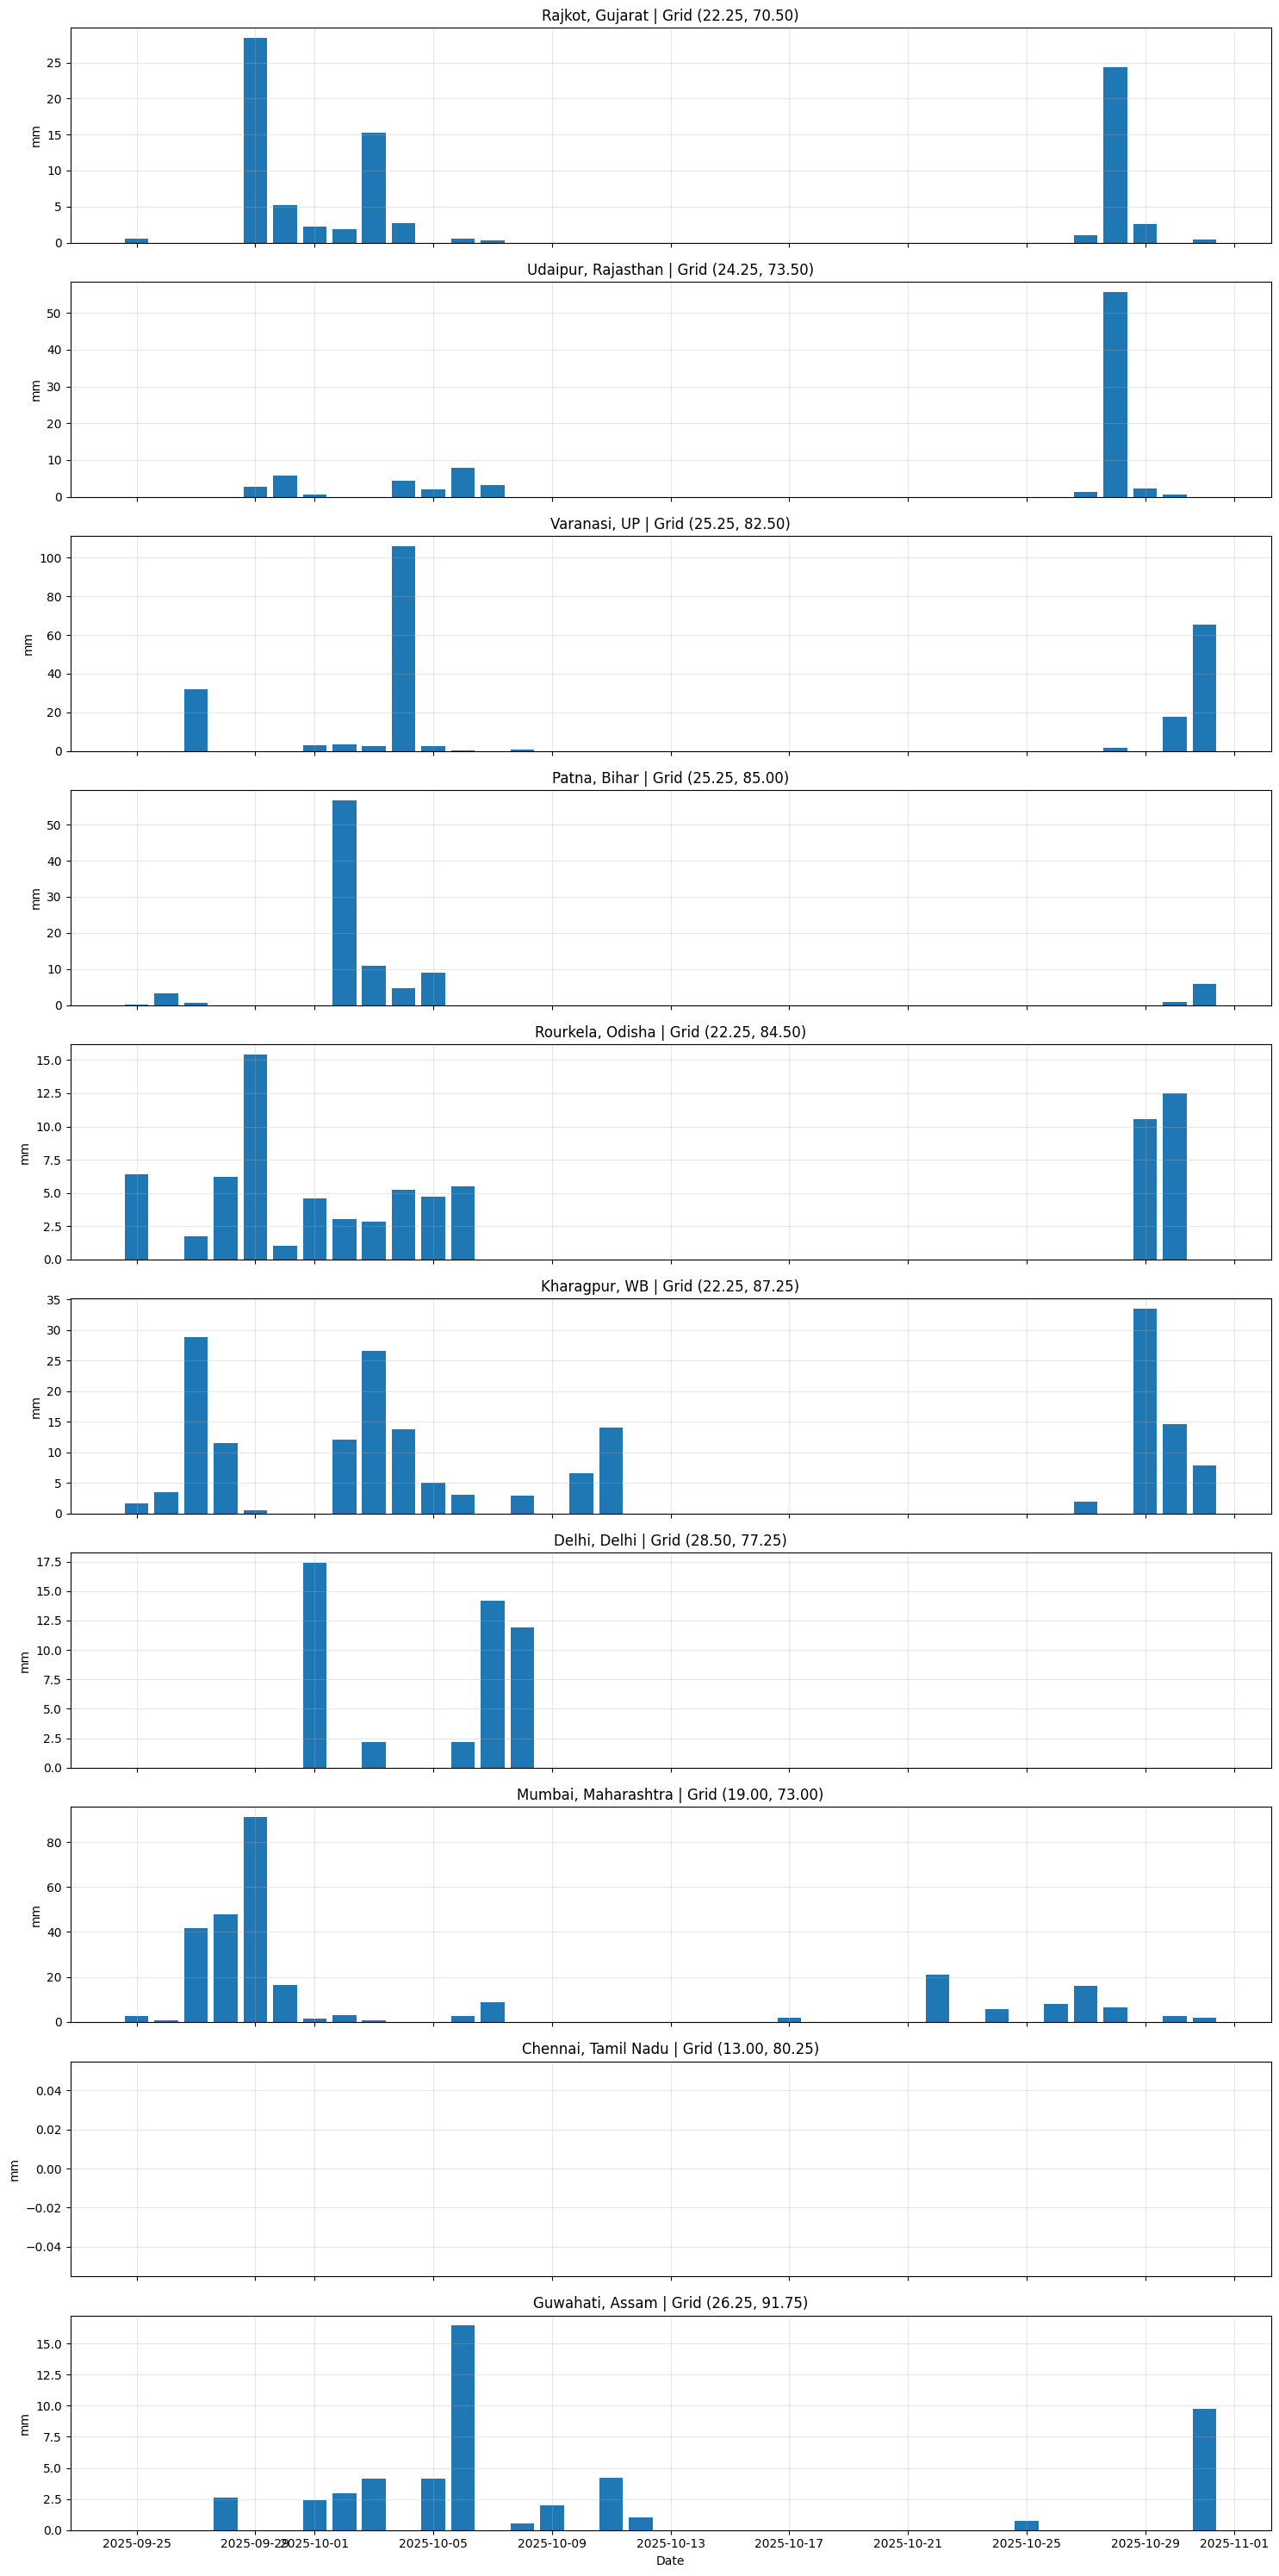

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# USER INPUT
# ==================================================

nc_file = r"C:\Users\hp\Downloads\RF25_ind2025_rfp25.nc"

start_date = "2025-09-25"
end_date   = "2025-10-31"

locations = [
    ("Rajkot, Gujarat",   22.18, 70.48),
    ("Udaipur, Rajasthan",  24.34, 73.42),
    ("Varanasi, UP", 25.18, 82.57),
    ("Patna, Bihar",   25.34, 85.08),
    ("Rourkela, Odisha", 22.15, 84.51),
    ("Kharagpur, WB", 22.35, 87.32),
    ("Delhi, Delhi",     28.61, 77.21),
    ("Mumbai, Maharashtra",    19.07, 72.88),
    ("Chennai, Tamil Nadu",   13.08, 80.27),
    ("Guwahati, Assam",  26.14, 91.74),
]

# ==================================================
# READ DATA
# ==================================================

ds = xr.open_dataset(nc_file)

nloc = len(locations)

fig, axes = plt.subplots(
    nloc,
    1,
    figsize=(15, 3*nloc),
    sharex=True
)

if nloc == 1:
    axes = [axes]

# ==================================================
# LOOP THROUGH LOCATIONS
# ==================================================

for ax, (name, lat, lon) in zip(axes, locations):

    rain = ds["RAINFALL"].sel(
        LATITUDE=lat,
        LONGITUDE=lon,
        method="nearest"
    )

    actual_lat = float(rain.LATITUDE.values)
    actual_lon = float(rain.LONGITUDE.values)

    rain_period = rain.sel(
        TIME=slice(start_date, end_date)
    )

    df = rain_period.to_dataframe().reset_index()

    # Bar plot
    ax.bar(
        df["TIME"],
        df["RAINFALL"],
        width=0.8
    )

    ax.set_ylabel("mm")

    ax.set_title(
        f"{name} | Grid ({actual_lat:.2f}, {actual_lon:.2f})"
    )

    ax.grid(True, alpha=0.3)

plt.xlabel("Date")

plt.tight_layout()
plt.show()

# Time series BAR PLOT same as above, but for 45 years


Found 46 files

Dataset loaded successfully

Rainfall variable: RAINFALL
Rajkot, Gujarat: Requested (22.18,70.48) → IMD Grid (22.25,70.50)
Udaipur, Rajasthan: Requested (24.34,73.42) → IMD Grid (24.25,73.50)
Varanasi, UP: Requested (25.18,82.57) → IMD Grid (25.25,82.50)
Patna, Bihar: Requested (25.34,85.08) → IMD Grid (25.25,85.00)
Rourkela, Odisha: Requested (22.15,84.51) → IMD Grid (22.25,84.50)
Kharagpur, WB: Requested (22.35,87.32) → IMD Grid (22.25,87.25)
Delhi, Delhi: Requested (28.61,77.21) → IMD Grid (28.50,77.25)
Mumbai, Maharashtra: Requested (19.07,72.88) → IMD Grid (19.00,73.00)
Chennai, Tamil Nadu: Requested (13.08,80.27) → IMD Grid (13.00,80.25)
Guwahati, Assam: Requested (26.14,91.74) → IMD Grid (26.25,91.75)


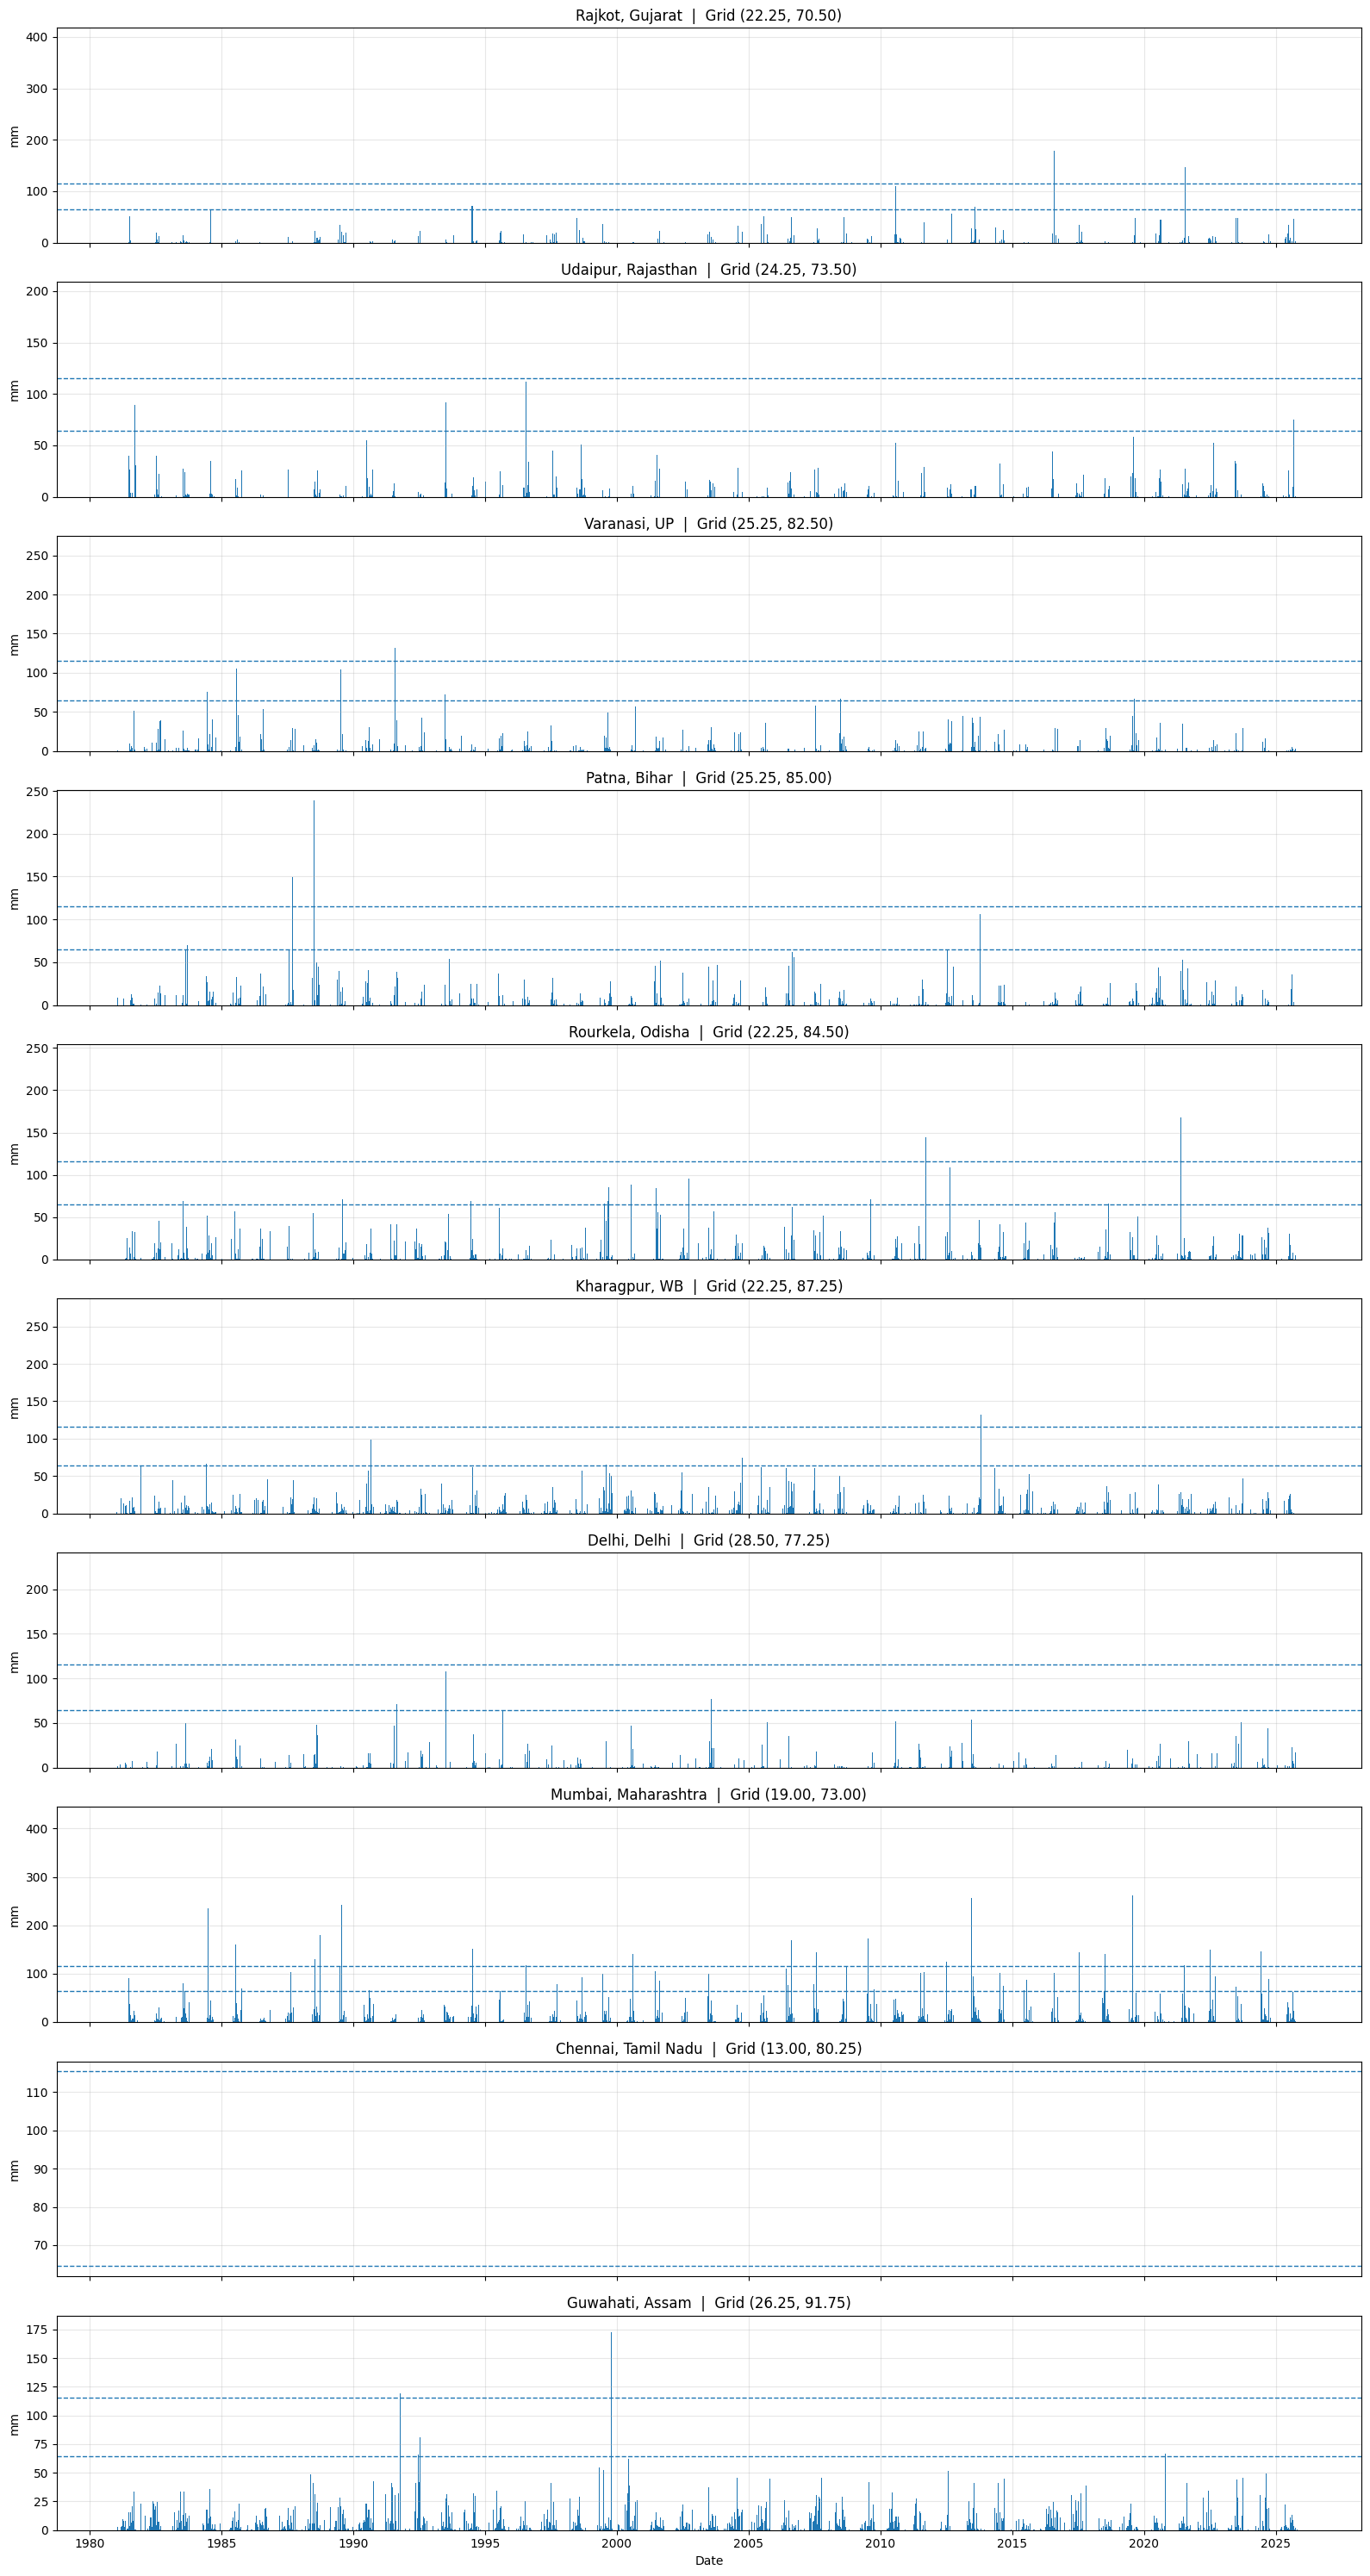


Excel saved: IMD_Rainfall_1981-01-01_to_2025-12-31.xlsx


In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# =====================================================
# USER INPUT
# =====================================================

data_dir = r"D:\PHD 2025~\1.SERVER_1\DATA\2. IMD GRIED (0.25X0.25) RAINFALL"

start_date = "1981-01-01"
end_date   = "2025-12-31"

locations = [
    ("Rajkot, Gujarat",   22.18, 70.48),
    ("Udaipur, Rajasthan",  24.34, 73.42),
    ("Varanasi, UP", 25.18, 82.57),
    ("Patna, Bihar",   25.34, 85.08),
    ("Rourkela, Odisha", 22.15, 84.51),
    ("Kharagpur, WB", 22.35, 87.32),
    ("Delhi, Delhi",     28.61, 77.21),
    ("Mumbai, Maharashtra",    19.07, 72.88),
    ("Chennai, Tamil Nadu",   13.08, 80.27),
    ("Guwahati, Assam",  26.14, 91.74),
]

# =====================================================
# READ ALL FILES
# =====================================================

nc_files = sorted(
    glob.glob(
        os.path.join(data_dir, "*.nc")
    )
)

print(f"\nFound {len(nc_files)} files")

ds = xr.open_mfdataset(
    nc_files,
    combine="by_coords"
)

print("\nDataset loaded successfully")

# =====================================================
# DETERMINE VARIABLE NAME
# =====================================================

rain_var = list(ds.data_vars)[0]

print(f"\nRainfall variable: {rain_var}")

# =====================================================
# PLOT
# =====================================================

nloc = len(locations)

fig, axes = plt.subplots(
    nloc,
    1,
    figsize=(16, 3*nloc),
    sharex=True
)

if nloc == 1:
    axes = [axes]

all_data = []

# =====================================================
# LOOP OVER LOCATIONS
# =====================================================

for ax, (name, lat, lon) in zip(axes, locations):

    rain = ds[rain_var].sel(
        LATITUDE=lat,
        LONGITUDE=lon,
        method="nearest"
    )

    actual_lat = float(rain.LATITUDE.values)
    actual_lon = float(rain.LONGITUDE.values)

    rain_ts = rain.sel(
        TIME=slice(start_date, end_date)
    )

    df = rain_ts.to_dataframe().reset_index()

    df["Location"] = name

    all_data.append(df)

    print(
        f"{name}: Requested ({lat:.2f},{lon:.2f}) "
        f"→ IMD Grid ({actual_lat:.2f},{actual_lon:.2f})"
    )

    # ---------------------------------
    # BAR PLOT
    # ---------------------------------

    ax.bar(
        df["TIME"],
        df[rain_var],
        width=1.0
    )

    ax.set_ylabel("mm")

    ax.set_title(
        f"{name}  |  Grid ({actual_lat:.2f}, {actual_lon:.2f})"
    )

    # IMD rainfall categories

    ax.axhline(
        64.5,
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        115.5,
        linestyle="--",
        linewidth=1
    )

    ax.grid(alpha=0.3)

# =====================================================
# FIGURE SETTINGS
# =====================================================

plt.xlabel("Date")

plt.tight_layout()

plt.show()

# =====================================================
# SAVE EXCEL
# =====================================================

combined_df = pd.concat(
    all_data,
    ignore_index=True
)

output_excel = (
    f"IMD_Rainfall_{start_date}_to_{end_date}.xlsx"
)

combined_df.to_excel(
    output_excel,
    index=False
)

print(f"\nExcel saved: {output_excel}")

# Creating merged Rainfall dataset for IMD gridded data of 45 years

In [4]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import os

# ==========================================================
# USER INPUT
# ==========================================================

data_dir = r"D:\PHD 2025~\1.SERVER_1\DATA\2. IMD GRIED (0.25X0.25) RAINFALL"

# ==========================================================
# FIND FILES
# ==========================================================

files = sorted(glob.glob(os.path.join(data_dir, "*.nc")))

print("\n==================================================")
print(f"FOUND {len(files)} FILES")
print("==================================================")

if len(files) == 0:
    raise FileNotFoundError("No NetCDF files found.")

for f in files[:5]:
    print(os.path.basename(f))

if len(files) > 5:
    print("...")

# ==========================================================
# OPEN FILES
# ==========================================================

print("\nOpening files...")

ds = xr.open_mfdataset(
    files,
    combine="nested",
    concat_dim="TIME",
    parallel=True
)

# ==========================================================
# SORT TIME
# ==========================================================

print("Sorting time...")

ds = ds.sortby("TIME")

# ==========================================================
# REMOVE DUPLICATE TIMES
# ==========================================================

print("Checking duplicate timestamps...")

_, unique_idx = np.unique(
    ds.TIME.values,
    return_index=True
)

n_before = ds.sizes["TIME"]

ds = ds.isel(TIME=np.sort(unique_idx))

n_after = ds.sizes["TIME"]

print(f"Removed {n_before - n_after} duplicate dates")

# ==========================================================
# RAIN VARIABLE
# ==========================================================

rain_var = list(ds.data_vars)[0]

print(f"\nRainfall Variable = {rain_var}")

# ==========================================================
# VERIFY TIME AXIS
# ==========================================================

print("\nVerifying chronology...")

start_date = pd.Timestamp(ds.TIME.values[0])
end_date = pd.Timestamp(ds.TIME.values[-1])

actual_dates = pd.to_datetime(ds.TIME.values)

expected_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D"
)

missing_dates = expected_dates.difference(actual_dates)

print(f"Start Date    : {start_date.date()}")
print(f"End Date      : {end_date.date()}")
print(f"Expected Days : {len(expected_dates)}")
print(f"Actual Days   : {len(actual_dates)}")

if len(missing_dates) > 0:

    print("\nWARNING: Missing Dates Found")

    print(f"Missing Count = {len(missing_dates)}")

    for d in missing_dates[:20]:
        print(d.date())

else:

    print("\n✓ No missing dates detected")

# ==========================================================
# SAVE MERGED FILE
# ==========================================================

merged_file = os.path.join(
    data_dir,
    "IMD_Rainfall_Merged.nc"
)

print("\nSaving merged file...")

encoding = {
    rain_var: {
        "zlib": True,
        "complevel": 4
    }
}

ds.to_netcdf(
    merged_file,
    encoding=encoding
)

print("Merged file saved.")

# ==========================================================
# REMOVE FEB 29
# ==========================================================

print("\nRemoving Feb-29 for climatology/anomaly...")

is_feb29 = (
    (ds.TIME.dt.month == 2)
    &
    (ds.TIME.dt.day == 29)
)

ds_no_leap = ds.sel(
    TIME=~is_feb29
)

print(
    f"Removed {int(is_feb29.sum())} leap-day records"
)

# ==========================================================
# CREATE MONTH-DAY COORDINATE
# ==========================================================

month_day = ds_no_leap.TIME.dt.strftime("%m-%d")

ds_no_leap = ds_no_leap.assign_coords(
    month_day=("TIME", month_day.values)
)

# ==========================================================
# DAILY CLIMATOLOGY
# ==========================================================

print("\nComputing climatology...")

clim = (
    ds_no_leap[rain_var]
    .groupby("month_day")
    .mean("TIME")
)

clim_ds = clim.to_dataset(
    name="CLIMATOLOGY"
)

clim_file = os.path.join(
    data_dir,
    "IMD_Daily_Climatology.nc"
)

clim_ds.to_netcdf(
    clim_file,
    encoding={
        "CLIMATOLOGY": {
            "zlib": True,
            "complevel": 4
        }
    }
)

print("Climatology saved.")

# ==========================================================
# DAILY ANOMALY
# ==========================================================

print("\nComputing anomaly...")

anom = (
    ds_no_leap[rain_var]
    .groupby("month_day")
    - clim
)

anom_ds = anom.to_dataset(
    name="ANOMALY"
)

anom_file = os.path.join(
    data_dir,
    "IMD_Daily_Anomaly.nc"
)

anom_ds.to_netcdf(
    anom_file,
    encoding={
        "ANOMALY": {
            "zlib": True,
            "complevel": 4
        }
    }
)

print("Anomaly saved.")

# ==========================================================
# DAILY RECORD HIGH
# ==========================================================

print("\nComputing record highs...")

record_high = (
    ds_no_leap[rain_var]
    .groupby("month_day")
    .max("TIME")
)

record_ds = record_high.to_dataset(
    name="RECORD_HIGH"
)

record_file = os.path.join(
    data_dir,
    "IMD_Daily_Record_High.nc"
)

record_ds.to_netcdf(
    record_file,
    encoding={
        "RECORD_HIGH": {
            "zlib": True,
            "complevel": 4
        }
    }
)

print("Record-high file saved.")

# ==========================================================
# FINAL SUMMARY
# ==========================================================

print("\n==================================================")
print("PROCESS COMPLETED")
print("==================================================")

print("\nOUTPUT FILES")

print(f"\n1. Merged")
print(merged_file)

print(f"\n2. Climatology")
print(clim_file)

print(f"\n3. Anomaly")
print(anom_file)

print(f"\n4. Record High")
print(record_file)

print("\nFinished successfully.")


FOUND 46 FILES
RF25_ind1980_rfp25.nc
RF25_ind1981_rfp25.nc
RF25_ind1982_rfp25.nc
RF25_ind1983_rfp25.nc
RF25_ind1984_rfp25.nc
...

Opening files...
Sorting time...
Checking duplicate timestamps...
Removed 0 duplicate dates

Rainfall Variable = RAINFALL

Verifying chronology...
Start Date    : 1980-01-01
End Date      : 2025-12-31
Expected Days : 16802
Actual Days   : 16802

✓ No missing dates detected

Saving merged file...
Merged file saved.

Removing Feb-29 for climatology/anomaly...
Removed 12 leap-day records

Computing climatology...
Climatology saved.

Computing anomaly...
Anomaly saved.

Computing record highs...


d:\PHD 2025~\PHD\VS CODES\era5_env\Lib\site-packages\dask\array\reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


Record-high file saved.

PROCESS COMPLETED

OUTPUT FILES

1. Merged
D:\PHD 2025~\1.SERVER_1\DATA\2. IMD GRIED (0.25X0.25) RAINFALL\IMD_Rainfall_Merged.nc

2. Climatology
D:\PHD 2025~\1.SERVER_1\DATA\2. IMD GRIED (0.25X0.25) RAINFALL\IMD_Daily_Climatology.nc

3. Anomaly
D:\PHD 2025~\1.SERVER_1\DATA\2. IMD GRIED (0.25X0.25) RAINFALL\IMD_Daily_Anomaly.nc

4. Record High
D:\PHD 2025~\1.SERVER_1\DATA\2. IMD GRIED (0.25X0.25) RAINFALL\IMD_Daily_Record_High.nc

Finished successfully.
